<a href="https://colab.research.google.com/github/philpos17/dhbw-kartoffel-sortierung/blob/main/code/colab/potato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Prüfen, welche Grafikkarte Google uns zugewiesen hat (sollte Tesla T4 sein)
!nvidia-smi

# Ultralytics (YOLO) und Roboflow im Hintergrund installieren (-q für quiet)
%pip install -q roboflow ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [3]:
from roboflow import Roboflow
!pip install roboflow

from google.colab import userdata
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

from roboflow import Roboflow
rf = Roboflow(api_key="QWgN4cgJcLf5zTtCkuhq")
project = rf.workspace("ms-workspace-m1gci").project("my-first-project-h62tp")
dataset = project.version(6).download("yolov8")

print(f"Datensatz erfolgreich in folgendes Verzeichnis geladen: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-6 in yolov8:: 100%|██████████| 2819/2819 [00:00<00:00, 8797.55it/s]

Datensatz erfolgreich in folgendes Verzeichnis geladen: /content/My-First-Project-6


Gefundene Klassen: ['bad', 'cut', 'potato', 'stone']

Anzahl der analysierten Bilder (Label-Dateien): 1407
Gesamtzahl der Bounding Boxen (Instanzen): 29747

--- Verteilung der Klassen ---
potato: 26149 Instanzen (87.9%)
bad: 2204 Instanzen (7.4%)
cut: 53 Instanzen (0.2%)
stone: 1341 Instanzen (4.5%)


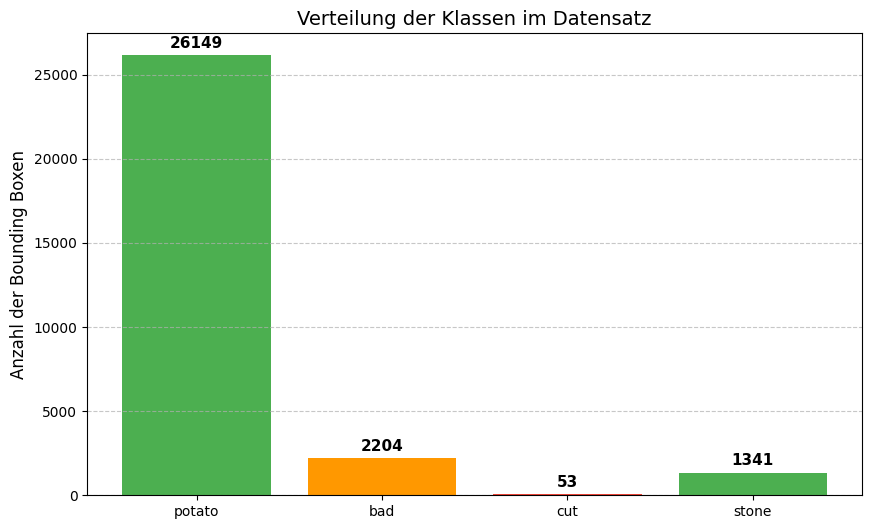

In [ ]:
import os
import glob
import yaml
import matplotlib.pyplot as plt
from collections import Counter

# 1. Pfad zur Konfigurationsdatei deines Datensatzes
yaml_path = f"{dataset.location}/data.yaml"

# Yaml-Datei laden, um die Klassennamen zu bekommen
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

classes = data_yaml['names']
print(f"Gefundene Klassen: {classes}")

# 2. Alle Label-Dateien (.txt) im Datensatz suchen
# Wir schauen in die Ordner train, valid und test
label_files = glob.glob(f"{dataset.location}/**/labels/*.txt", recursive=True)

print(f"\nAnzahl der analysierten Bilder (Label-Dateien): {len(label_files)}")

# 3. Alle Bounding Boxen zählen
class_counts = Counter()
total_boxes = 0

for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            # Das YOLO Format ist: [class_id] [x_center] [y_center] [width] [height]
            parts = line.strip().split()
            if len(parts) >= 1:
                class_id = int(parts[0])
                class_counts[class_id] += 1
                total_boxes += 1

print(f"Gesamtzahl der Bounding Boxen (Instanzen): {total_boxes}\n")

# 4. Verteilung ausgeben
print("--- Verteilung der Klassen ---")
for class_id, count in class_counts.items():
    class_name = classes[class_id]
    percentage = (count / total_boxes) * 100 if total_boxes > 0 else 0
    print(f"{class_name}: {count} Instanzen ({percentage:.1f}%)")

# 5. Ein schönes Diagramm zeichnen
labels = [classes[class_id] for class_id in class_counts.keys()]
counts = list(class_counts.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, counts, color=['#4CAF50', '#FF9800', '#F44336'][:len(labels)])
plt.title('Verteilung der Klassen im Datensatz', fontsize=14)
plt.ylabel('Anzahl der Bounding Boxen', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Zahlen auf die Balken schreiben
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts)*0.01),
             int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

In [ ]:
from ultralytics import YOLO

# Wir laden das vortrainierte Nano-Modell (optimal für schnelle Inferenz am Jetson)
model = YOLO('yolov8n.pt')

# Das Training starten
results = model.train(
    data=f"{dataset.location}/data.yaml", # Pfad zur Konfigurationsdatei deines Datensatzes
    epochs=50,                            # Maximale Anzahl der Trainingsrunden
    imgsz=640,                            # YOLOv8 Standard-Auflösung
    batch=16,                             # 16 Bilder werden gleichzeitig in den VRAM der GPU geladen
    patience=10,                          # Early Stopping: Bricht ab, falls das Modell 10 Runden nicht besser wird
    project='Kartoffel_Sorter',           # Überordner für die Ergebnisse
    name='YOLOv8n_Iteration_1',           # Unterordner für diesen spezifischen Durchlauf
    plots=True                            # Generiert automatisch Graphen (wichtig für die Ausarbeitung!)
)

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/My-First-Project-6/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_Iteration_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [ ]:
import shutil
from google.colab import files

# Der Pfad, unter dem YOLO das beste Modell dieser Trainingsrunde gespeichert hat
best_model_path = '/content/runs/detect/Kartoffel_Sorter/YOLOv8n_Iteration_1/weights/best.pt'
download_path = '/content/kartoffel_modell_best.pt'

# Datei ins Hauptverzeichnis kopieren und Download anstoßen
shutil.copy(best_model_path, download_path)
files.download(download_path)

print("Download des Modells gestartet. Diese .pt Datei brauchst du für den Jetson!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download des Modells gestartet. Diese .pt Datei brauchst du für den Jetson!


In [ ]:
import shutil
from google.colab import files

# 1. Den Pfad zum Ordner definieren
folder_to_zip = '/content/runs/detect/Kartoffel_Sorter/YOLOv8n_Iteration_1'

# 2. Den gewünschten Namen und Speicherort für die ZIP-Datei festlegen
# Hinweis: shutil hängt das '.zip' automatisch an diesen Namen an
zip_file_name = '/content/Kartoffel_Ergebnisse_Iteration1'

# 3. Den gesamten Ordner packen
print("Ordner wird gezippt... Bitte warten.")
shutil.make_archive(zip_file_name, 'zip', folder_to_zip)

# 4. Die fertige ZIP-Datei auf dein MacBook herunterladen
print("Download startet gleich!")
files.download(zip_file_name + '.zip')

Ordner wird gezippt... Bitte warten.
Download startet gleich!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>